In [225]:
TICKER = "2330.TW"
TRAIN_START_TIME = "2020-01-01"
TRAIN_END_TIME = "2024-12-31"
PRED_START_TIME = "2025-01-01"
PRED_END_TIME = "2025-12-31"
INTERVAL = "1d"
FEATURES = [
    "Close",
    # "Volume",
    # "trend_sma_fast",
    # "trend_sma_slow",
    # "trend_macd",
    # "trend_macd_signal",
    # "trend_macd_diff",
    # "momentum_stoch",
    # "momentum_stoch_signal",
    # "momentum_rsi",
    # "volatility_bbm",
    # "volatility_bbh",
    # "volatility_bbl",
    # "volatility_bbw",
    # "volatility_bbp",
    # "trend_adx",
    # "trend_adx_pos",
    # "trend_adx_neg",
]
SEQ_LEN = 60

In [226]:
import ta
import yfinance as yf
from datetime import datetime, timedelta


def download_data(ticker: str, start_time: str, end_time: str, interval: str):
    start_time_new = datetime.strptime(start_time, "%Y-%m-%d")
    start_time_new = start_time_new - timedelta(days=SEQ_LEN * 3)

    df = yf.download(
        ticker,
        start=start_time_new,
        end=end_time,
        interval=interval,
    )
    if df is None or df.empty:
        raise ValueError("Failed to download train data")

    df.columns = df.columns.droplevel(1)
    df = ta.add_all_ta_features(
        df, open="Open", high="High", low="Low", close="Close", volume="Volume"
    )
    # print(df.columns)
    # print(df.loc[df['trend_macd_diff'] < 0, ["trend_macd", "trend_macd_signal", "trend_macd_diff"]])

    df_prev, df = df[:start_time], df[start_time:]
    data_prev, data = df_prev[FEATURES].to_numpy(), df[FEATURES].to_numpy()

    return data_prev, data

In [227]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler


scaler = None


def scale_data(
    data_prev: np.ndarray, train: np.ndarray, val: np.ndarray | None = None
) -> tuple[np.ndarray, np.ndarray, np.ndarray | None]:
    global scaler

    scaler = MinMaxScaler()
    scaler.fit(np.concatenate((data_prev, train)))

    data_prev_scaled = scaler.transform(data_prev)
    train_scaled = scaler.transform(train)
    val_scaled = scaler.transform(val) if val is not None else None

    return data_prev_scaled, train_scaled, val_scaled


def inverse_scale_data(data: np.ndarray, num_features: int) -> np.ndarray:
    global scaler

    if scaler is None:
        raise ValueError("Scaler has not been fitted yet")

    dummy = np.zeros((len(data), num_features))
    dummy[:, 0] = data[:, 0]
    data_inv = scaler.inverse_transform(dummy)

    scaler = None

    return data_inv[:, 0]

In [228]:
import numpy as np


def create_sequences(
    data: np.ndarray, data_prev: np.ndarray | None = None, seq_len: int = 60
) -> tuple[np.ndarray, np.ndarray]:
    X, y = [], []

    if data_prev is not None:
        data = np.concatenate((data_prev[-seq_len:], data))
    for i in range(seq_len, len(data)):
        X.append(data[i - seq_len : i])
        y.append(data[i, 0])

    return np.array(X), np.array(y).reshape(-1, 1)

In [229]:
import keras
from keras.models import Sequential
from keras.layers import (
    Input,
    LSTM,
    Dropout,
    Dense,
    MultiHeadAttention,
    LayerNormalization,
    GlobalAveragePooling1D,
)


class SelfAttentionBlock(keras.layers.Layer):
    def __init__(self, num_heads=4, key_dim=16, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha = MultiHeadAttention(
            num_heads=num_heads, key_dim=key_dim, dropout=dropout
        )
        self.norm = LayerNormalization()

    def call(self, x):
        attn = self.mha(x, x)
        return self.norm(x + attn)


def build_model(shape: tuple[int, int]) -> keras.Model:
    keras.backend.clear_session()

    model = Sequential(
        [
            Input(shape=shape),
            # LSTM(64, return_sequences=True),
            # Dropout(0.2),
            LSTM(64, return_sequences=True),
            Dropout(0.2),
            LSTM(64),
            Dropout(0.2),
            # LSTM(64, return_sequences=True),
            # Dropout(0.2),
            # SelfAttentionBlock(num_heads=4, key_dim=16, dropout=0.1),
            # GlobalAveragePooling1D(),
            # Dense(32, activation="relu"),
            Dense(1),
        ]
    )
    model.compile(optimizer="adam", loss="mse")

    return model

In [230]:
from keras.callbacks import ReduceLROnPlateau, EarlyStopping


def train_model(
    model: keras.Model,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
) -> keras.callbacks.History:
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        callbacks=[
            ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5),
            EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        ],
    )

    return history

In [231]:
import matplotlib.pyplot as plt


def plot_results(history: dict) -> None:
    _, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(history["loss"], label="Train Loss")
    axes[0].plot(history["val_loss"], label="Validation Loss")
    axes[0].set_title("Model Loss")
    axes[0].legend()

    axes[1].plot(history["actual"], label="Actual")
    axes[1].plot(history["predicted"], label="Predicted")
    axes[1].set_title("Predict Results")
    axes[1].legend()
    # axes[1].text(
    #     0.05,
    #     -0.3,
    #     f"Ticker: {TICKER}\nStart Time: {START_TIME}\nInterval: {INTERVAL}\nFeatures: {','.join(FEATURES)}\nSequence Length: {SEQ_LEN}",
    #     transform=axes[1].transAxes,
    # )
    axes[1].text(
        0.55,
        -0.3,
        f"Accuracy: {1 - history['mape']:.2%}",
        transform=axes[1].transAxes,
    )

    plt.tight_layout()
    plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.2076 - val_loss: 0.1723 - learning_rate: 0.0010
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0335 - val_loss: 0.0515 - learning_rate: 0.0010
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0148 - val_loss: 0.1861 - learning_rate: 0.0010
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0125 - val_loss: 0.0322 - learning_rate: 0.0010
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.0114 - val_loss: 0.0252 - learning_rate: 0.0010
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0079 - val_loss: 0.0378 - learning_rate: 0.0010
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0069 - val_loss: 0.0111 - learning_rate: 0.0010
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0064 - val_loss: 0.0153 - learning_rate: 0.0010
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0066 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 10/100
7/7 ━━━━━━━━━━━

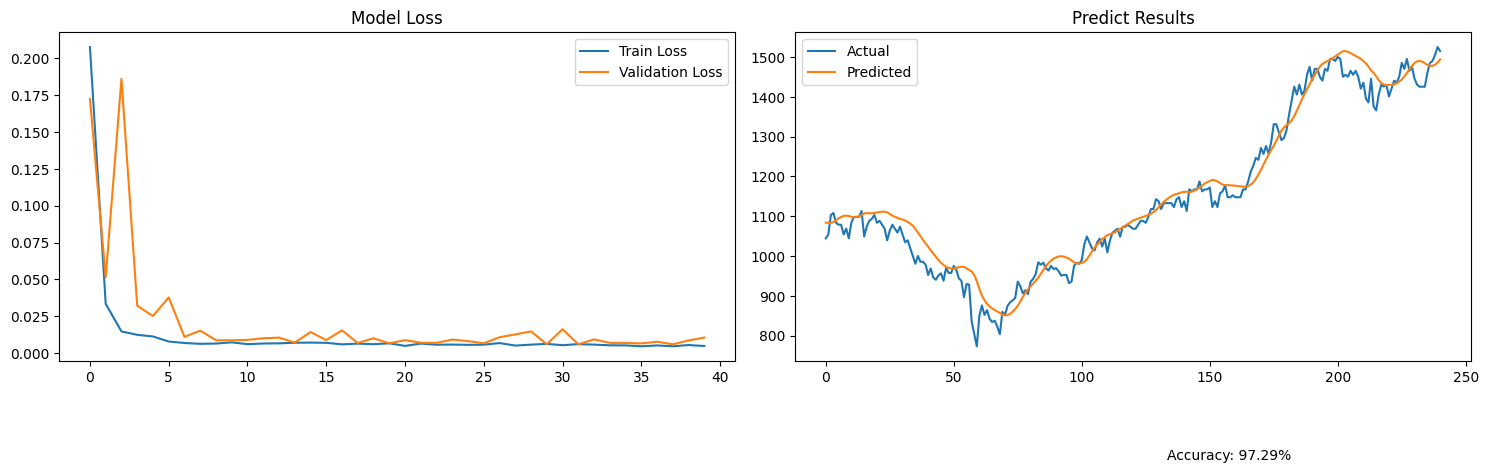

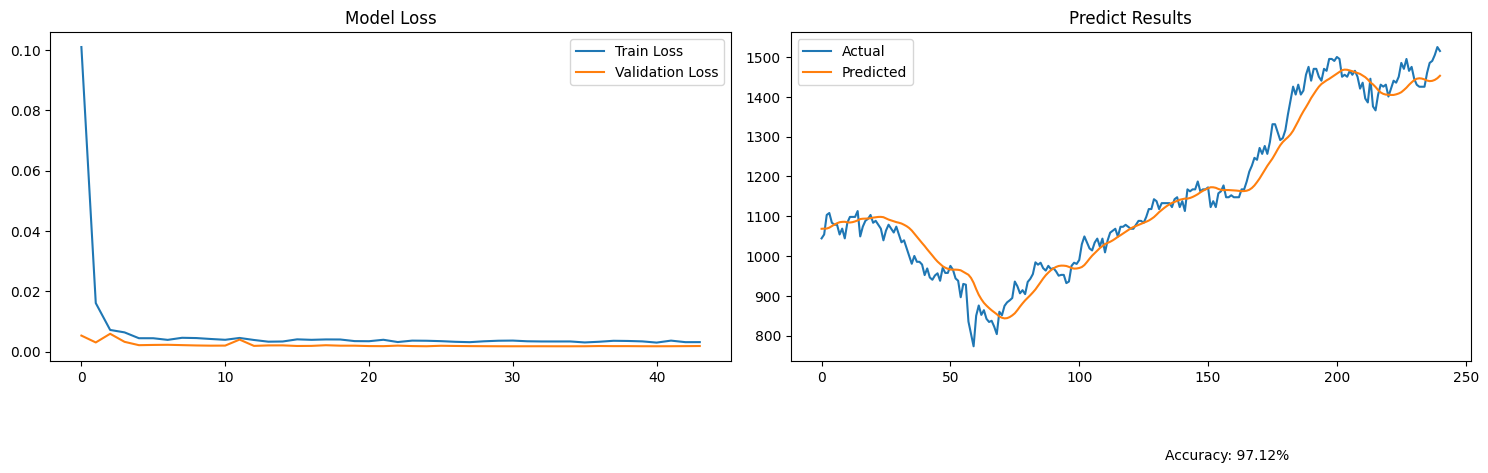

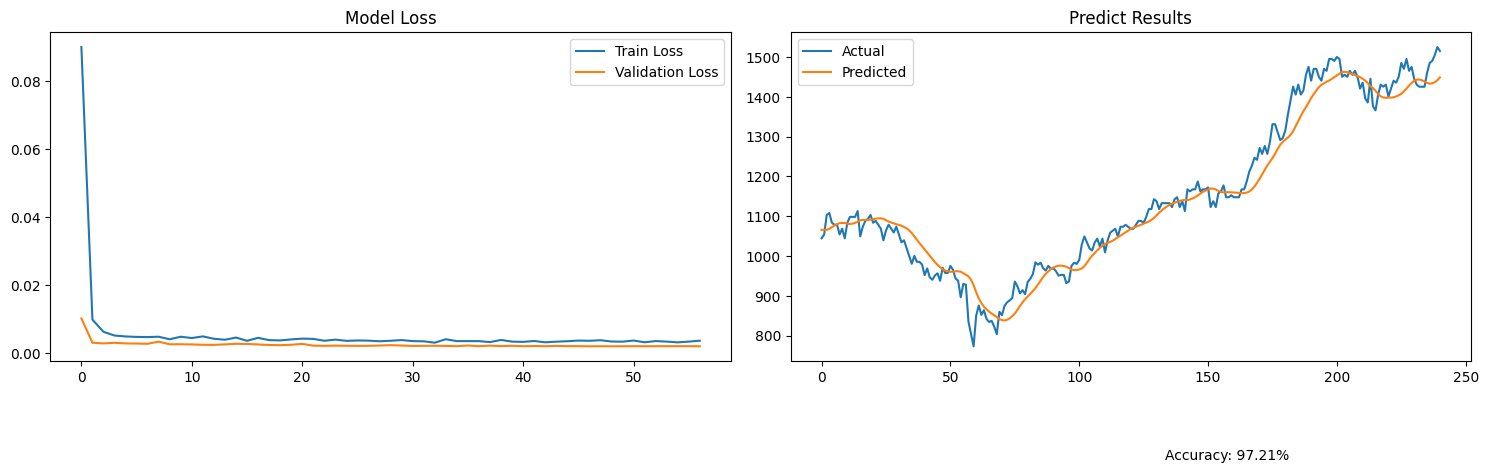

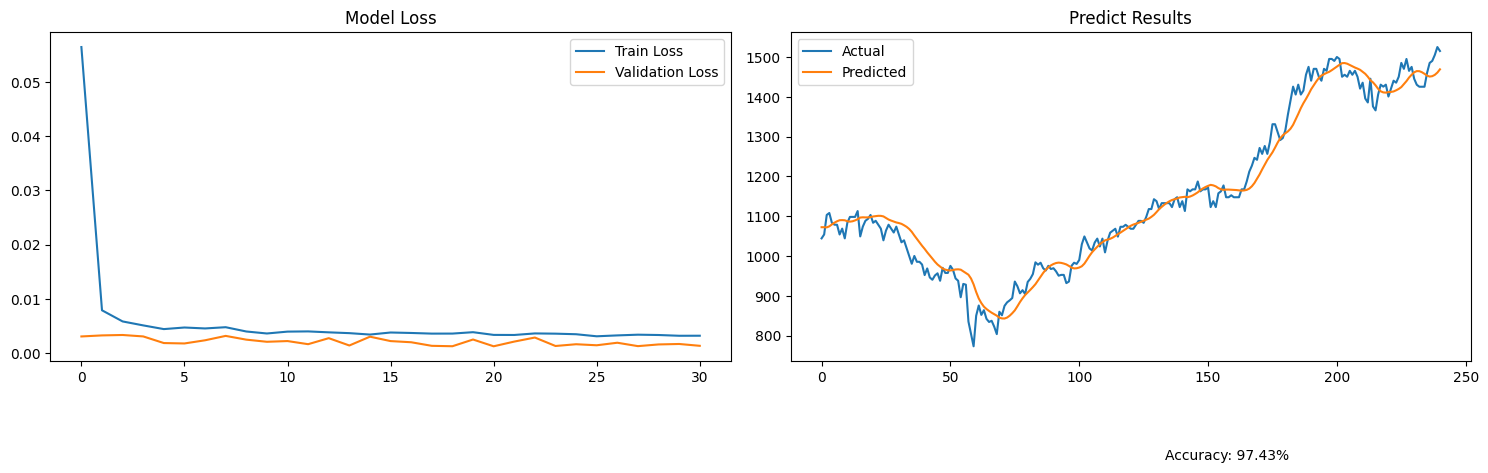

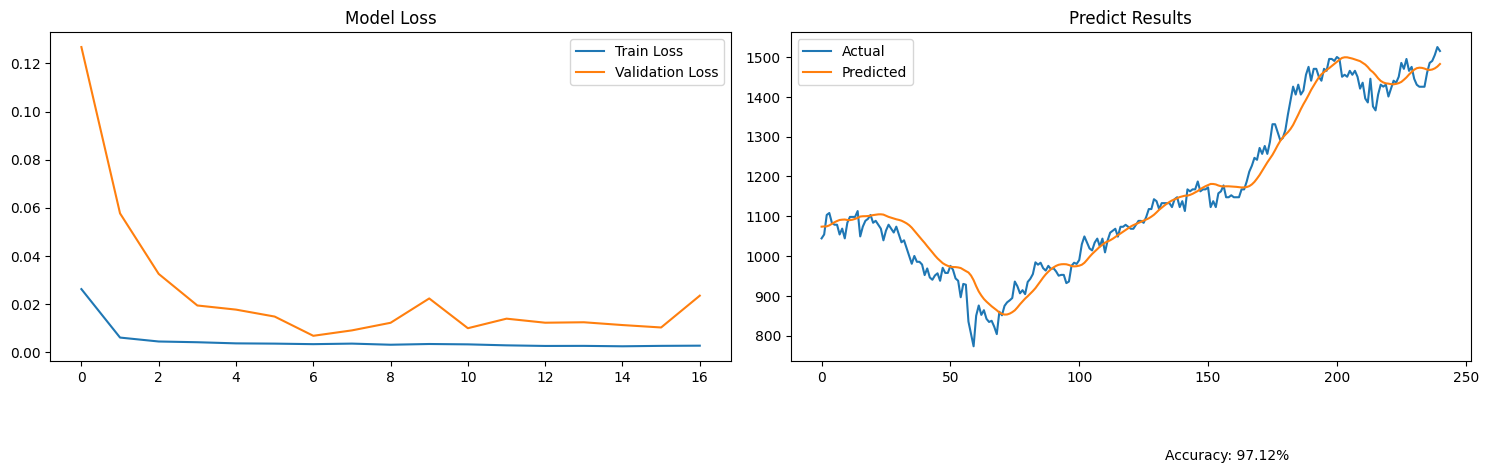

In [232]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_percentage_error


data_prev, data = download_data(TICKER, TRAIN_START_TIME, TRAIN_END_TIME, INTERVAL)
data_pred_prev, data_pred = download_data(
    TICKER, PRED_START_TIME, PRED_END_TIME, INTERVAL
)

tscv = TimeSeriesSplit(n_splits=5)
fold_mape, fold_histories = [], []
for fold, (train_idx, val_idx) in enumerate(tscv.split(data), start=1):
    # ----- Train -----
    train, val = data[train_idx], data[val_idx]
    data_prev_scaled, train_scaled, val_scaled = scale_data(data_prev, train, val)
    assert val_scaled is not None

    X_train, y_train = create_sequences(train_scaled, data_prev_scaled, SEQ_LEN)
    X_val, y_val = create_sequences(val_scaled, train_scaled, SEQ_LEN)

    model = build_model((SEQ_LEN, len(FEATURES)))
    history = train_model(model, X_train, y_train, X_val, y_val)

    # ----- Predict -----
    data_pred_prev_scaled, data_pred_scaled, _ = scale_data(data_pred_prev, data_pred)
    y_actual = data_pred[:, 0]
    X_pred, _ = create_sequences(data_pred_scaled, data_pred_prev_scaled, SEQ_LEN)

    y_pred = model.predict(X_pred)
    y_pred_inv = inverse_scale_data(y_pred, len(FEATURES))

    mape = mean_absolute_percentage_error(y_actual, y_pred_inv)
    fold_mape.append(mape)
    fold_histories.append(
        history.history | {"actual": y_actual, "predicted": y_pred_inv, "mape": mape}
    )

    print(f"Fold {fold} MAPE: {mape:.4%} | Accuracy: {1 - mape:.2%}")

mape_mean = np.mean(fold_mape)
mape_std = np.std(fold_mape)

print("-" * 50)
print(
    f"Cross-Validation MAPE: {mape_mean:.4%} ± {mape_std:.4%} | Accuracy: {1 - mape_mean:.2%} ± {mape_std:.2%}"
)
for history in fold_histories:
    plot_results(history)